In [1]:
import numpy as np
import matplotlib.pyplot as plt
import func

import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
})

In [3]:
Delta = 0.04
k = 100
d = 200

sig = lambda x: tf.nn.tanh(2*x) - 0.729477*x
sig_np = lambda x: np.tanh(2*x) - 0.729477*x


g, dg, l_e, m_e, l_s, m_s = func.sig_related(sig_np)

In [4]:
alphas_exp = np.linspace(0, 3, 21)[1:]

errs_hmc = []
for iter in range(16):
    filename = f'err_data_beta_03/iter_{iter+1}.csv'
    errs_hmc.append(np.loadtxt(filename))
errs_hmc = np.array(errs_hmc)
errs_mean = np.mean(errs_hmc, axis=0)
errs_std = np.std(errs_hmc, axis=0)



In [5]:
alphas = np.linspace(0, 3, 201)
alphas_ = np.linspace(0, 0.5, 101)

v = func.v_generate(k, beta=0.3)

errs = [func.solve(int(alpha*d**2), d, Delta, v, g, m_e)[0] for alpha in alphas]
errs_ = [func.solve(int(alpha*d**2), d, Delta, v, g, m_e)[0] for alpha in alphas_]


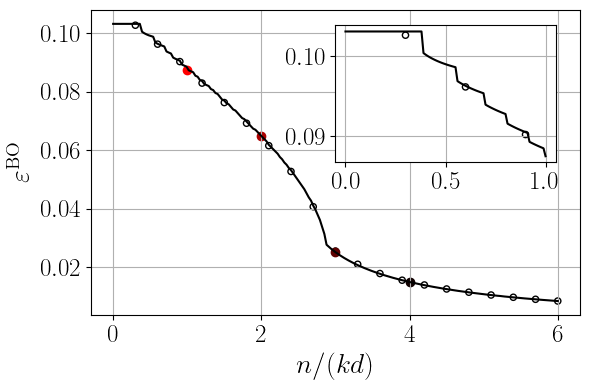

In [6]:
colors = [ "#FF0000", "#AD0000", "#5E0000", "#100000"]
alphas_v = [0.5, 1, 1.5, 2]


width, height = 6, 4
size, lsize = 18, 20
fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)
ax.tick_params(axis='both', labelsize=size)
ax.set_xlabel(r'$n/(kd)$', fontsize=lsize)
ax.set_ylabel(r'$\varepsilon^{\rm BO}$', fontsize=lsize)

inset_ax = ax.inset_axes([0.5, 0.5, 0.45, 0.45])  
inset_ax.set_xticks([0, 0.5, 1])
inset_ax.set_yticks([0.08, 0.09, 0.1])
inset_ax.tick_params(axis='both', labelsize=size)

color = 'black'
ax.plot(2*alphas, errs, color=color)
ax.scatter(2*alphas_exp, errs_mean, marker='o', facecolors='none', edgecolors=color, s=20) ###

alphas_exp_inset = alphas_exp[alphas_exp<=0.5]
L = len(alphas_exp_inset)
inset_ax.plot(2*alphas_, errs_, color=color)
inset_ax.scatter(2*alphas_exp_inset, errs_mean[:L], marker='o', facecolors='none', edgecolors=color, s=20) ###


for alpha, color in zip(alphas_v, colors):
    err = func.solve(int(alpha*d**2), d, Delta, v, g, m_e)[0]
    plt.scatter([2*alpha], [err], color=color)


ax.grid()
inset_ax.grid(True)
plt.savefig('figs/learning_curve_beta_03.pdf')
plt.show()